# Icescopy counts to INP per litre of air with INP-toolkit

Step-by-step analysis of the M1 base-rerun dataset, from freezing counts to INP concentrations per litre of air.

In [1]:
from dataclasses import asdict
from pathlib import Path
import csv
import hashlib
import io
import json
import zipfile
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "inptk-matplotlib"))

# Use this checkout when launched from the project or its notebook folder.
# Otherwise use an installed inptk package.
project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/inptk").is_dir()),
    None,
)
if project_root is not None:
    sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import inptk

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.max_columns = 12
print(f"INP-toolkit {inptk.__version__}: {inptk.__file__}")

INP-toolkit 0.4.0: /Users/C832577250/Project/inptk/src/inptk/__init__.py


## 1. Choose the input and settings

Average uses automatic limits with at least 3 frozen and 3 liquid sample wells,
except that `Sample_0` keeps all warm-end observations. Its automatic cold limit
still applies. MLE uses the manual limits below. Both use the same raw observations,
blank assignments and 50 µL well volume.

Optional sampling onto a 0.25 °C grid happens after calculation. The selected
skip-decreases policy omits lower Average points and keeps later points once
the concentration recovers. It does not terminate the curve at the first dip.


In [2]:
DATA_PATH = Path("/Volumes/Hailstone Data/demo (M1) 08.12.25 base rerun/freeze_count_timeseries.csv")
OLAF_REFERENCE_PATH = Path(
    "/Volumes/Hailstone Data/Mentor data from Carson/(M1) 08.12.25 base rerun/"
    "INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25 base rerun.csv"
)
PROJECT_PATH = DATA_PATH.with_name("demo.icescopy")
RUN_ID = "M1-base-rerun"
SAMPLE_MAP = {f"Sample_{i}": "CRG_M1" for i in range(5)}
PLOT_SAMPLE_ID = "CRG_M1"
PLOT_CYCLE_ID = "0"
COMBINED_CURVE_ID = "CRG_M1"
CURVES = {COMBINED_CURVE_ID: {"inputs": list(SAMPLE_MAP), "cycle": PLOT_CYCLE_ID}}
OUTPUT_STEP_C = 0.25  # Optional: applied only to the final result.
OUTPUT_METHOD = "sample"  # Or "interpolate" for a derived curve.
MLE_TEMPERATURE_RANGES_C = {
    "Sample_1": {"max_C": -10},
    "Sample_2": {"max_C": -15},
    "Sample_3": {"max_C": -20},
    "Sample_4": {"max_C": -25},
}
AVERAGE_MIN_FROZEN = 3
AVERAGE_MIN_UNFROZEN = 3
METHOD = "average"  # Or "mle"; each method uses its own limits.
DECREASE_POLICY = "skip_decreases"  # Skip dips and resume when concentration recovers.
TEMPERATURE_XLIM = (-30, -5)  # Temperature increases from left to right.

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Mount the data drive or update DATA_PATH: {DATA_PATH}")

## 2. Recover raw counts from the saved Icescopy project

The CSV contains blank-adjusted counts with changing totals. Joint MLE needs the
original wells, so use the saved project’s cell assignments and freezing-image
indices. The CSV supplies temperature and time for each actual image. Rows without
an image are omitted. `Sample_5` is the raw assay blank.

This M1 example has 32 wells per input, 50 µL per well, and 482 images.
The recovery below is specific to this saved project; new Icescopy exports should
provide raw counts directly.

In [3]:
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
project_sha256 = hashlib.sha256(PROJECT_PATH.read_bytes()).hexdigest()
preamble, header_rows = {}, {}
with DATA_PATH.open(encoding="utf-8") as stream:
    for line in stream:
        if not line.startswith("#"):
            break
        body = line[1:].strip()
        fields = next(csv.reader([body]))
        if len(fields) > 1:
            header_rows[fields[0]] = fields[1:]
        elif ":" in body:
            key, value = body.split(":", 1)
            preamble[key.strip()] = value.strip()
well_volume_uL = float(preamble["well_volume_uL"])
assert well_volume_uL == 50

with zipfile.ZipFile(PROJECT_PATH) as archive:
    session = json.loads(archive.read("session.json"))
    events = pd.read_csv(io.BytesIO(archive.read("freeze.csv")))
raw_export = pd.read_csv(DATA_PATH, comment="#", dtype={"cycle": str})
observations = raw_export.loc[raw_export.picture.notna()].copy()
image_indices = {name: i for i, name in enumerate(session["image_names"])}
observations["image_index"] = observations.picture.map(image_indices)
assert observations.image_index.notna().all()
assert observations.image_index.nunique() == len(observations) == 482
assert observations.cycle.unique().tolist() == ["0"]
assert len(events) == events.cell.nunique() == 192
assert session["last_temperature_blank_sample_names"] == ["Sample_5"]
timestamps = pd.to_datetime(observations.timestamp)
observations["time_s"] = (timestamps - timestamps.iloc[0]).dt.total_seconds()

count_frames, source_metadata = [], []
for identity, metadata in session["sample_catalog"].items():
    name = metadata["sample_name"]
    cells = [cell for cell in session["cell_records_by_id"].values()
             if cell["sample_id"] == identity]
    assert len(cells) == 32 and all(len(cell["freeze_event_indices"]) == 1 for cell in cells)
    freezes = sorted(cell["freeze_event_indices"][0] for cell in cells)
    recorded = events.loc[events.cell.isin([f"cell_{cell['cell_id']}" for cell in cells]),
                          "image_index"]
    assert sorted(recorded) == freezes
    frame = observations[["cycle", "temperature_C", "time_s", "picture"]].rename(
        columns={"cycle": "cycle_id", "picture": "picture_id"}).copy()
    frame["measurement_id"] = name
    frame["n_total"] = len(cells)
    frame["n_frozen"] = np.searchsorted(freezes, observations.image_index, side="right")
    count_frames.append(frame)
    record = {"measurement_id": name, "sample_id": "water" if name == "Sample_5" else "CRG_M1",
              "run_id": RUN_ID, "droplet_volume_uL": well_volume_uL,
              "dilution": 1 if name == "Sample_5" else float(metadata["dilution"])}
    if name != "Sample_5":
        record.update(sample_type="air", air_volume_L=float(metadata["air_volume_L"]),
                      suspension_volume_mL=float(metadata["suspension_volume_mL"]),
                      filter_fraction_used=float(metadata["filter_fraction_used"]))
    source_metadata.append(record)
display(pd.DataFrame(source_metadata))
print(f"Recovered {len(observations)} actual image observations; 192 physical wells.")

,measurement_id,sample_id,run_id,droplet_volume_uL,dilution,sample_type,air_volume_L,suspension_volume_mL,filter_fraction_used
0,Sample_0,CRG_M1,M1-base-rerun,50.0,1.0,air,17829.1,10.0,1.0
1,Sample_1,CRG_M1,M1-base-rerun,50.0,13.0,air,17829.1,10.0,1.0
2,Sample_2,CRG_M1,M1-base-rerun,50.0,169.0,air,17829.1,10.0,1.0
3,Sample_3,CRG_M1,M1-base-rerun,50.0,2197.0,air,17829.1,10.0,1.0
4,Sample_4,CRG_M1,M1-base-rerun,50.0,28561.0,air,17829.1,10.0,1.0
5,Sample_5,water,M1-base-rerun,50.0,1.0,NaN,NaN,NaN,NaN


Recovered 482 actual image observations; 192 physical wells.


In [4]:
water_blank_map = {name: ["Sample_5"] for name in SAMPLE_MAP}
imported = inptk.read_counts(
    pd.concat(count_frames, ignore_index=True), metadata=source_metadata,
    water_blank_map=water_blank_map,
)
preparation = {"operation": "recover_raw_first_freezing_counts_from_icescopy_project",
               "actual_images": len(observations), "physical_wells": 192,
               "omitted_temperature_only_rows": len(raw_export) - len(observations)}
experiment = inptk.Experiment(
    counts=inptk.CountsTable(imported.counts.to_dataframe(), history=[preparation]),
    samples=imported.samples, measurements=imported.measurements,
    water_blank_map=water_blank_map,
    source={"format": "icescopy_project_raw_events", "path": str(PROJECT_PATH),
            "sha256": project_sha256, "temperature_csv": str(DATA_PATH),
            "temperature_csv_sha256": source_sha256},
)
raw_counts = experiment.counts.to_dataframe()
raw_counts["fraction_frozen"] = raw_counts.n_frozen / raw_counts.n_total
display(raw_counts.groupby(["sample_id", "run_id", "cycle_id", "measurement_id"],
                          sort=False).size().rename("observation_rows").to_frame())
plot_selection = dict(sample_id=PLOT_SAMPLE_ID, run_id=RUN_ID, cycle_id=PLOT_CYCLE_ID)
selected_counts = experiment.counts.select(**plot_selection).to_dataframe()
selected_counts["fraction_frozen"] = selected_counts.n_frozen / selected_counts.n_total

observation_rows
sample_id run_id        cycle_id measurement_id                  
CRG_M1    M1-base-rerun 0        Sample_0                     482
                                 Sample_1                     482
                                 Sample_2                     482
                                 Sample_3                     482
                                 Sample_4                     482
water     M1-base-rerun 0        Sample_5                     482

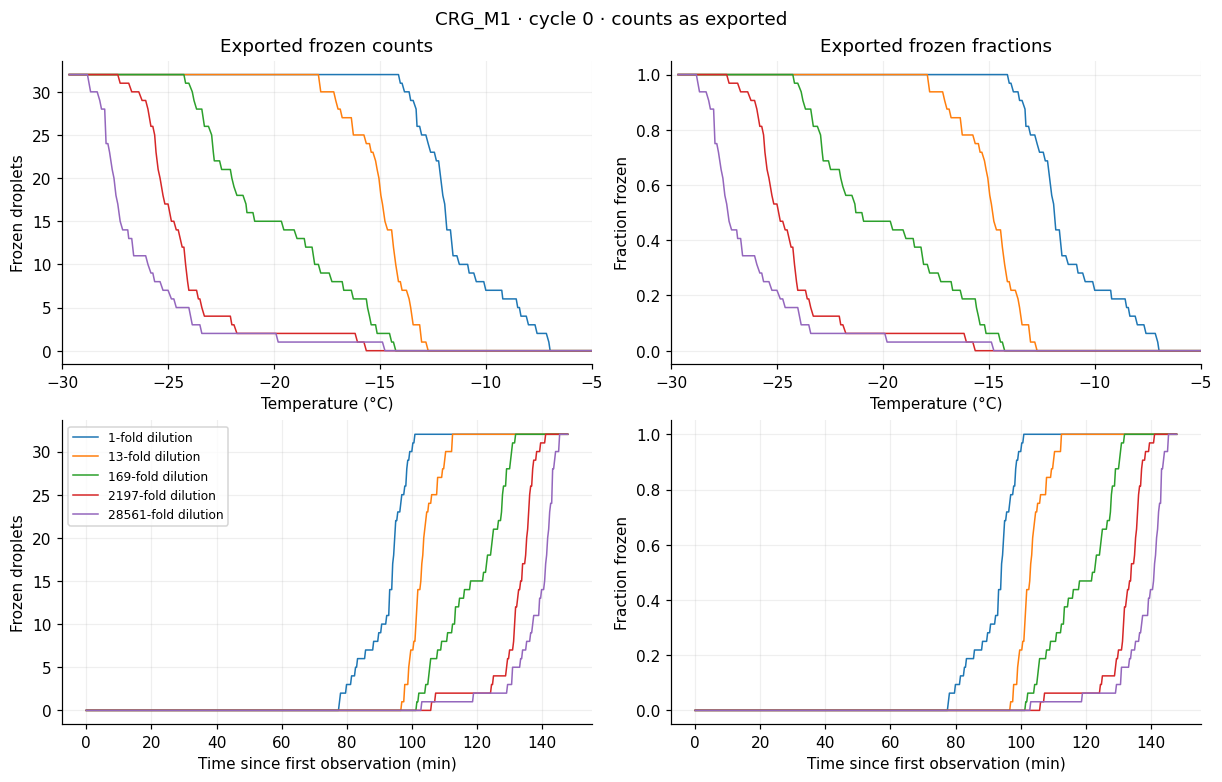

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout="constrained")
for measurement_id, frame in selected_counts.groupby("measurement_id", sort=False):
    dilution = experiment.measurements[measurement_id].dilution
    label = f"{dilution:g}-fold dilution"
    frame = frame.sort_values("time_s")
    axes[0, 0].plot(frame.temperature_C, frame.n_frozen, lw=1, label=label)
    axes[0, 1].plot(frame.temperature_C, frame.fraction_frozen, lw=1, label=label)
    axes[1, 0].plot(frame.time_s / 60, frame.n_frozen, lw=1, label=label)
    axes[1, 1].plot(frame.time_s / 60, frame.fraction_frozen, lw=1, label=label)
axes[0, 0].set(title="Exported frozen counts", xlabel="Temperature (°C)", ylabel="Frozen droplets", xlim=TEMPERATURE_XLIM)
axes[0, 1].set(title="Exported frozen fractions", xlabel="Temperature (°C)", ylabel="Fraction frozen", xlim=TEMPERATURE_XLIM)
axes[1, 0].set(xlabel="Time since first observation (min)", ylabel="Frozen droplets")
axes[1, 1].set(xlabel="Time since first observation (min)", ylabel="Fraction frozen")
for ax in axes.flat:
    ax.grid(alpha=0.2)
axes[1, 0].legend(fontsize=8, loc="upper left")
fig.suptitle(f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · counts as exported")
plt.show()

## 3. Calculate frozen fractions at the original observations

`frozen_fraction()` adds frozen count divided by total count. It preserves every
supplied observation and temperature, including repeated temperatures and small
warming steps. Repeated observations do not increase the number of droplets.


Original frozen-fraction observations: 2,892


,sample_id,cycle_id,measurement_id,temperature_C,n_total,n_frozen,fraction_frozen
0,CRG_M1,0,Sample_0,20.614,32,0,0.0
1,CRG_M1,0,Sample_0,20.613,32,0,0.0
2,CRG_M1,0,Sample_0,20.623,32,0,0.0
3,CRG_M1,0,Sample_0,20.587,32,0,0.0
4,CRG_M1,0,Sample_0,20.616,32,0,0.0


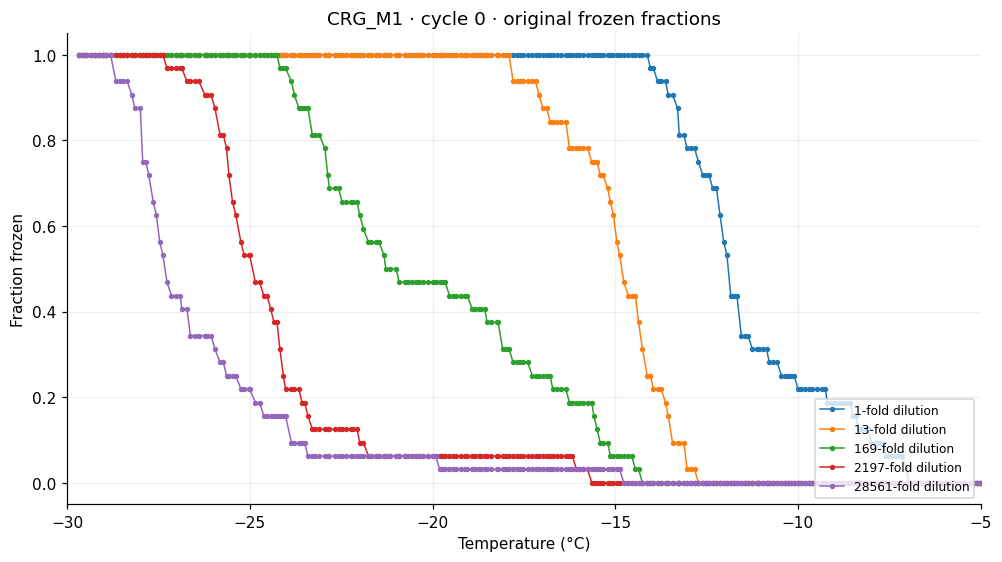

In [6]:
fractions = inptk.frozen_fraction(experiment)
fraction_df = fractions.to_dataframe()
print(f"Original frozen-fraction observations: {len(fraction_df):,}")
display(fraction_df[["sample_id", "cycle_id", "measurement_id", "temperature_C", "n_total", "n_frozen", "fraction_frozen"]].head())

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for measurement_id, frame in fractions.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False):
    frame = frame.sort_values("time_s", kind="stable")
    dilution = experiment.measurements[measurement_id].dilution
    ax.plot(frame.temperature_C, frame.fraction_frozen, "o-", ms=2.5, lw=1, label=f"{dilution:g}-fold dilution")
ax.set(title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · original frozen fractions", xlabel="Temperature (°C)", ylabel="Fraction frozen", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.2)
plt.show()

### Applied temperature limits

Use the suggested limits for Average, then remove the warm cutoff for `Sample_0`
(the least-diluted input). Its first freezing observations remain available.
Blank flags do not remove points. Zero concentrations remain in the tables but
cannot be drawn on the logarithmic concentration axis.


In [7]:
auto_suggestions = inptk.suggest_temperature_ranges(
    experiment, curves=CURVES,
    min_frozen=AVERAGE_MIN_FROZEN, min_unfrozen=AVERAGE_MIN_UNFROZEN,
)
RANGES_BY_METHOD = {
    "mle": MLE_TEMPERATURE_RANGES_C,
    "average": auto_suggestions.temperature_ranges_C,
}
# Preserve the initial observations of the least-diluted input.
RANGES_BY_METHOD["average"]["Sample_0"]["max_C"] = None
display(pd.DataFrame.from_dict(auto_suggestions.inputs, orient="index"))
auto_report = auto_suggestions.observations.to_dataframe()
display(auto_report.groupby(["measurement_id", "blank_status"]).size().rename("observations"))


,run_id,cycle_id,range_C,status,kept_observations,excluded_observations,warm_limit_reason,cold_limit_reason
Sample_0,M1-base-rerun,0,"{'min_C': -13.548, 'max_C': -7.676}",suggested,63,419,[too_few_frozen],[too_few_liquid]
Sample_1,M1-base-rerun,0,"{'min_C': -17.087, 'max_C': -13.124}",suggested,41,441,[too_few_frozen],[too_few_liquid]
Sample_2,M1-base-rerun,0,"{'min_C': -23.781, 'max_C': -15.205}",suggested,86,396,[too_few_frozen],[too_few_liquid]
Sample_3,M1-base-rerun,0,"{'min_C': -26.233, 'max_C': -21.893}",suggested,45,437,[too_few_frozen],[too_few_liquid]
Sample_4,M1-base-rerun,0,"{'min_C': -28.231, 'max_C': -23.503}",suggested,48,434,[too_few_frozen],[too_few_liquid]


measurement_id  blank_status                
Sample_0        distinguished_from_blank         63
                not_assessed_outside_range      419
Sample_1        distinguished_from_blank         41
                not_assessed_outside_range      441
Sample_2        distinguished_from_blank         86
                not_assessed_outside_range      396
Sample_3        distinguished_from_blank         33
                not_assessed_outside_range      437
                not_distinguished_from_blank     12
Sample_4        distinguished_from_blank          4
                not_assessed_outside_range      434
                not_distinguished_from_blank     44
Name: observations, dtype: int64

## 4. Calculate each input separately

Use the selected `METHOD` and its temperature limits. Average estimates each
observation separately; MLE fits each input's full freezing history. Both include
the assigned raw blank. Convert suspension concentration to INP per litre of air.


In [8]:
individual_suspension = inptk.cumulative_spectrum(
    fractions, experiment=experiment, method=METHOD,
    temperature_ranges_C=RANGES_BY_METHOD[METHOD],
)
individual_air = inptk.convert_concentration(
    individual_suspension, experiment.samples, basis="sampled_air",
)
sample = experiment.samples[PLOT_SAMPLE_ID]
print("Sample metadata:", asdict(sample))
print(f"Suspension-to-air multiplier: {sample.factor_for('sampled_air'):.10g}")
display(individual_air.select(**plot_selection).to_dataframe()[[
    "measurement_id", "temperature_C", "concentration", "lower_error", "upper_error", "unit",
]].head())

Sample metadata: {'sample_id': 'CRG_M1', 'sample_name': '', 'sample_type': 'air', 'air_volume_L': 17829.1, 'suspension_volume_mL': 10.0, 'filter_fraction_used': 1.0, 'dry_mass_g': None}
Suspension-to-air multiplier: 0.0005608808072


,measurement_id,temperature_C,concentration,lower_error,upper_error,unit
0,Sample_0,20.614,0.0,0.0,0.000673,INP_per_L_air
1,Sample_0,20.613,0.0,0.0,0.000673,INP_per_L_air
2,Sample_0,20.623,0.0,0.0,0.000673,INP_per_L_air
3,Sample_0,20.587,0.0,0.0,0.000673,INP_per_L_air
4,Sample_0,20.616,0.0,0.0,0.000673,INP_per_L_air


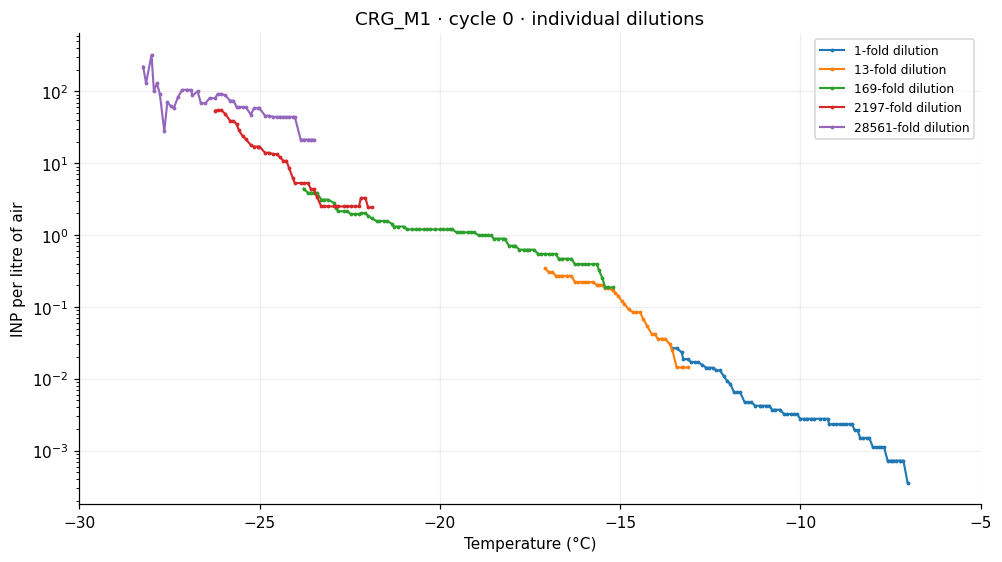

Log plots omit zero, negative and infinite concentrations; tables retain them.


In [9]:
def draw_spectrum(ax, frame, *, label, color, show_errors=False, linestyle="-", alpha=1):
    """Plot one selected curve; retain gaps where a log plot cannot show a value."""
    if "point_order" in frame:
        frame = frame.sort_values("point_order", kind="stable")
    elif "time_s" in frame:
        frame = frame.sort_values("time_s", kind="stable")
    # A new segment starts after an excluded observation; never connect across it.
    if "segment_id" in frame and frame.segment_id.nunique() > 1:
        for index, (_, segment) in enumerate(frame.groupby("segment_id", sort=False)):
            draw_spectrum(ax, segment, label=label if index == 0 else None,
                          color=color, show_errors=show_errors,
                          linestyle=linestyle, alpha=alpha)
        return
    visible = np.isfinite(frame.concentration) & (frame.concentration > 0)
    values = frame.concentration.where(visible)
    ax.plot(frame.temperature_C, values, color=color, linestyle=linestyle,
            marker=".", ms=3, lw=1.4, alpha=alpha, label=label)
    if show_errors:
        lower = frame.concentration - frame.lower_error
        upper = frame.concentration + frame.upper_error
        valid_band = visible & (lower > 0) & np.isfinite(lower) & np.isfinite(upper)
        ax.fill_between(frame.temperature_C, lower.where(valid_band), upper.where(valid_band),
                        color=color, alpha=0.13)


fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for index, (measurement_id, frame) in enumerate(individual_air.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False)):
    dilution = experiment.measurements[measurement_id].dilution
    draw_spectrum(ax, frame, label=f"{dilution:g}-fold dilution", color=f"C{index}")
ax.set(yscale="log", title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · individual dilutions",
       xlabel="Temperature (°C)", ylabel="INP per litre of air", xlim=TEMPERATURE_XLIM)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.show()
print("Log plots omit zero, negative and infinite concentrations; tables retain them.")

## 5. Fit the combined curve, then sample it

MLE fits one monotone sample curve and one blank curve to all selected freezing
histories. Each physical well contributes once. Temperature ranges select which
observations enter the fit; later data can also affect earlier estimates.

Average estimates concentration separately at each temperature and then takes an
equal-weight mean. Its curve can decrease when the contributors or blank change.
Average uses the automatic limits shown above. MLE uses the manual limits.
The selected decrease policy still applies to Average.

Shading shows nominal approximate 95% pointwise intervals. MLE refits the whole
curve and blank for each bound; the shaded area is not a simultaneous 95% band.
Sampling onto 0.25 °C happens only after fitting and final selection.

In [10]:
range_controls = pd.DataFrame([
    {
        "method": method,
        "measurement_id": name,
        "dilution": metadata.dilution,
        "min_C": RANGES_BY_METHOD[method].get(name, {}).get("min_C"),
        "max_C": RANGES_BY_METHOD[method].get(name, {}).get("max_C"),
    }
    for method in ("mle", "average")
    for name, metadata in experiment.measurements.items() if name in SAMPLE_MAP
])
display(range_controls)

combined_suspension = {
    method: inptk.estimate_concentration(
        fractions, experiment=experiment, method=method, curves=CURVES,
        temperature_ranges_C=RANGES_BY_METHOD[method],
    )
    for method in ("mle", "average")
}
combined_air_candidates = {
    method: inptk.convert_concentration(table, experiment.samples, basis="sampled_air")
    for method, table in combined_suspension.items()
}
combined_air = {
    method: inptk.finalize_spectrum(table, decrease_policy=DECREASE_POLICY)
    for method, table in combined_air_candidates.items()
}

grid_air = {
    method: inptk.resample_spectrum(table, step_C=OUTPUT_STEP_C, method=OUTPUT_METHOD)
    for method, table in combined_air.items()
}
combined_selection = {"curve_id": COMBINED_CURVE_ID}
print("Named concentration curve:", COMBINED_CURVE_ID)

for method, table in combined_air.items():
    print(f"{method}: {len(table):,} retained native points; warnings: {table.warnings or 'none'}")
    report = next(item for item in table.history[-1]["groups"]
                  if item["curve_id"] == combined_selection["curve_id"])
    first_decrease = next((item for item in report["excluded"] if item["reason"] == "decrease"), None)
    if first_decrease is not None:
        print(f"First decrease at {first_decrease['temperature_C']:.4g} °C: "
              f"{first_decrease['reference_concentration']:.6g} → "
              f"{first_decrease['concentration']:.6g} INP/L. Policy: {DECREASE_POLICY}.")
    selected = grid_air[method].select(**combined_selection).to_dataframe()
    display(selected.tail(5)[[
        "temperature_C", "concentration", "lower_error", "upper_error", "unit",
        "sampling_status",
    ]])
# The least-diluted input contributes from its first original observation.
average_candidates = combined_air_candidates["average"].to_dataframe()
assert average_candidates.temperature_C.iloc[0] == selected_counts.loc[
    selected_counts.measurement_id.eq("Sample_0"), "temperature_C"
].iloc[0]
assert "Sample_0" in json.loads(average_candidates.contributing_measurement_ids.iloc[0])
average_retained = combined_air["average"].to_dataframe()
print(f"Average retained range: {average_retained.temperature_C.max():.3f} to "
      f"{average_retained.temperature_C.min():.3f} °C.")


,method,measurement_id,dilution,min_C,max_C
0,mle,Sample_0,1.0,NaN,NaN
1,mle,Sample_1,13.0,NaN,-10.000
2,mle,Sample_2,169.0,NaN,-15.000
3,mle,Sample_3,2197.0,NaN,-20.000
4,mle,Sample_4,28561.0,NaN,-25.000
5,average,Sample_0,1.0,-13.548,NaN
6,average,Sample_1,13.0,-17.087,-13.124
7,average,Sample_2,169.0,-23.781,-15.205
8,average,Sample_3,2197.0,-26.233,-21.893
9,average,Sample_4,28561.0,-28.231,-23.503


Named concentration curve: CRG_M1
mle: 473 retained native points; warnings: ["{'sample_id': 'CRG_M1', 'curve_id': 'CRG_M1'}: final selection excluded 9 of 482 points using skip_decreases"]


,temperature_C,concentration,lower_error,upper_error,unit,sampling_status
192,-27.50,119.861784,66.860597,106.644772,INP_per_L_air,sampled
193,-27.75,129.149029,75.934402,145.649540,INP_per_L_air,sampled
194,-28.00,453.252301,221.485311,348.266207,INP_per_L_air,sampled
195,-28.25,545.421658,264.120690,424.834810,INP_per_L_air,sampled
196,-28.50,616.913801,327.365850,567.218630,INP_per_L_air,sampled


average: 446 retained native points; warnings: ["Curve 'CRG_M1': 13 points have no eligible input", "{'sample_id': 'CRG_M1', 'curve_id': 'CRG_M1'}: final selection excluded 36 of 482 points using skip_decreases"]
First decrease at -13.12 °C: 0.0170488 → 0.0165667 INP/L. Policy: skip_decreases.


,temperature_C,concentration,lower_error,upper_error,unit,sampling_status
178,-25.00,29.922790,27.049573,48.151168,INP_per_L_air,sampled
179,-25.50,42.260763,36.256262,58.041279,INP_per_L_air,sampled
180,-25.75,56.547662,45.700266,65.548308,INP_per_L_air,sampled
181,-26.00,68.664896,54.845050,72.640073,INP_per_L_air,sampled
182,-27.00,105.248214,105.248214,126.958204,INP_per_L_air,sampled


Average retained range: 20.623 to -27.998 °C.


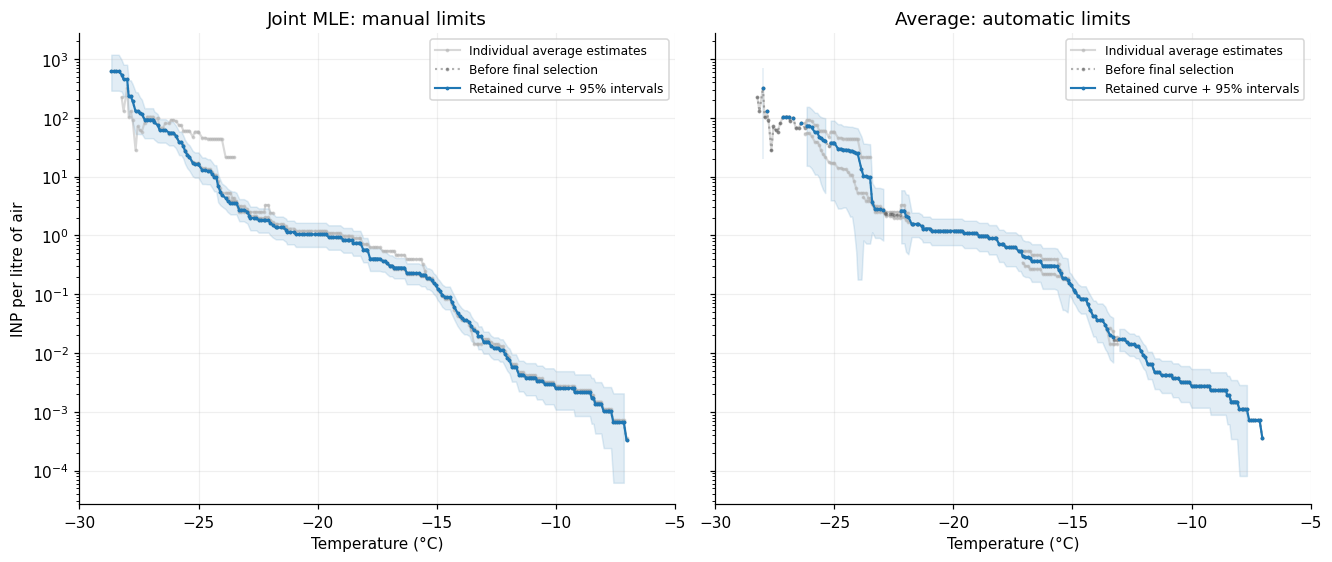

Intervals reaching zero cannot be shaded on the log axis. Saturated tails have no finite fit.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True,
                         layout="constrained")
for ax, method in zip(axes, ("mle", "average")):
    for index, (measurement_id, frame) in enumerate(
        individual_air.select(**plot_selection).to_dataframe().groupby("measurement_id", sort=False)
    ):
        draw_spectrum(ax, frame, label=f"Individual {METHOD} estimates" if index == 0 else None,
                      color="0.7", alpha=0.5)
    draw_spectrum(ax, combined_air_candidates[method].select(**combined_selection).to_dataframe(),
                  label="Before final selection", color="0.4", linestyle=":", alpha=0.5)
    draw_spectrum(ax, combined_air[method].select(**combined_selection).to_dataframe(),
                  label="Retained curve + 95% intervals", color="C0", show_errors=True)
    ax.set(yscale="log", title="Joint MLE: manual limits" if method == "mle" else "Average: automatic limits",
           xlabel="Temperature (°C)", xlim=TEMPERATURE_XLIM)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
axes[0].set_ylabel("INP per litre of air")
plt.show()
print("Intervals reaching zero cannot be shaded on the log axis. Saturated tails have no finite fit.")

## 6. Compare with the supplied OLAF final table

Compare the reference with the retained native MLE and Average curves. Plot native
points so isolated retained observations are visible even when they fall between
regular grid temperatures. Sampled results remain available separately in `grid_air`.
This comparison does not assume the methods should agree.


,site,start_time,end_time,filter_color,sample_type,vol_air_filt,proportion_filter_used,vol_susp,treatment,notes,user,IS
0,CRG_M1,2025-08-12 13:00:00,2025-08-13 13:00:00,white,air,17829.1,1.0,10,base,none,Carson,IS1a


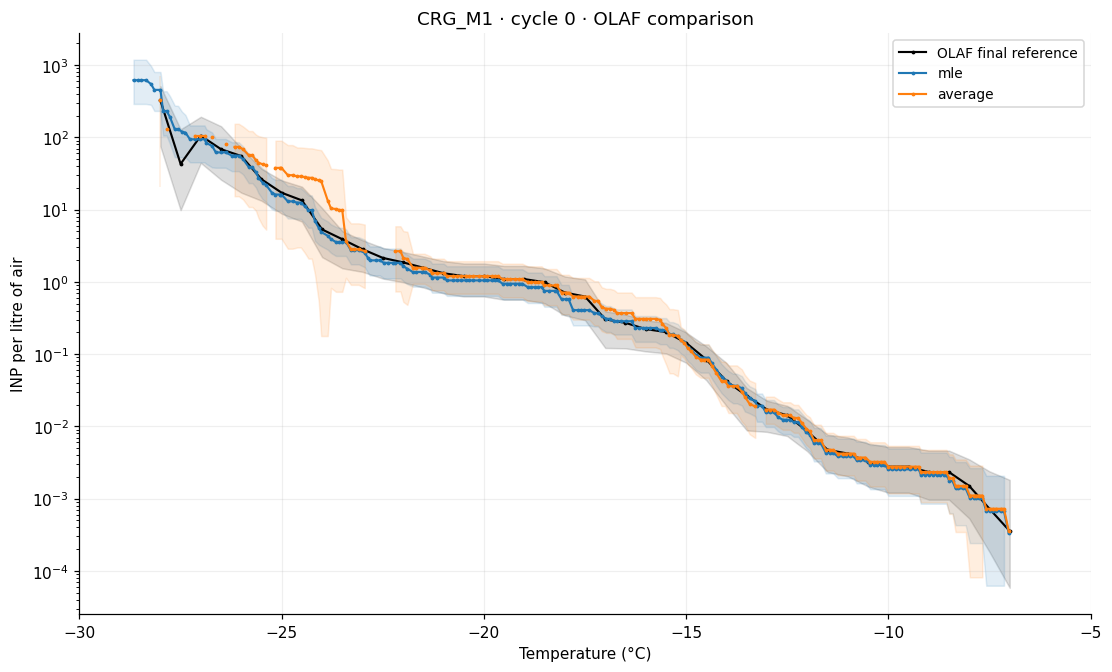

In [12]:
if OLAF_REFERENCE_PATH.is_file():
    reference_metadata = {}
    with OLAF_REFERENCE_PATH.open(encoding="utf-8") as stream:
        for header_index, line in enumerate(stream):
            if line.strip().startswith("degC,"):
                break
            if "=" in line:
                key, value = line.split("=", 1)
                reference_metadata[key.strip()] = value.strip()
        else:
            raise ValueError("OLAF reference is missing its degC header")
    reference = pd.read_csv(OLAF_REFERENCE_PATH, skiprows=header_index).rename(columns={
        "degC": "temperature_C", "INPS_L": "concentration",
        "lower_CI": "lower_error", "upper_CI": "upper_error",
    })
    for column in ("temperature_C", "concentration", "lower_error", "upper_error"):
        reference[column] = pd.to_numeric(reference[column], errors="raise")
    display(pd.DataFrame([reference_metadata]))
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    draw_spectrum(ax, reference, label="OLAF final reference", color="black", show_errors=True)
    for index, (label, table) in enumerate(combined_air.items()):
        draw_spectrum(ax, table.select(**combined_selection).to_dataframe(),
                      label=label, color=f"C{index}", show_errors=True)
    ax.set(yscale="log", title=f"{PLOT_SAMPLE_ID} · cycle {PLOT_CYCLE_ID} · OLAF comparison",
           xlabel="Temperature (°C)", ylabel="INP per litre of air", xlim=TEMPERATURE_XLIM)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.show()
else:
    print(f"Optional reference is unavailable: {OLAF_REFERENCE_PATH}")

## 7. Named individual and combined curves

Request the main curve and each individual input through the same interface.
The original counts and observed fractions remain available separately.


In [13]:
output_curves = {
    **CURVES,
    **{name: {"inputs": [name], "cycle": PLOT_CYCLE_ID} for name in SAMPLE_MAP},
}
result = inptk.analyze_concentration(
    experiment, method=METHOD, curves=output_curves,
    temperature_ranges_C=RANGES_BY_METHOD[METHOD],
    output_basis="sampled_air", output_step_C=OUTPUT_STEP_C,
    output_method=OUTPUT_METHOD, decrease_policy=DECREASE_POLICY,
)
curve = result.curves[COMBINED_CURVE_ID]
pd.testing.assert_frame_equal(result.counts.to_dataframe(), experiment.counts.to_dataframe())
pd.testing.assert_frame_equal(result.frozen_fraction.to_dataframe(), fractions.to_dataframe())
pd.testing.assert_frame_equal(
    curve.cumulative.to_dataframe(), combined_air[METHOD].select(**combined_selection).to_dataframe(),
)
pd.testing.assert_frame_equal(
    curve.resampled.to_dataframe(), grid_air[METHOD].select(**combined_selection).to_dataframe(),
)
assert list(result.curves) == list(output_curves)
for named_curve in result.curves.values():
    for source in named_curve.sources:
        selected = experiment.counts.select(
            measurement_id=source["measurement_id"], run_id=source["run_id"],
            cycle_id=source["cycle_id"],
        )
        assert len(selected)
display(pd.DataFrame([
    {"curve_id": name, "kind": value.kind, "inputs": len(value.sources),
     "retained_points": len(value.cumulative), "excluded_points": len(value.excluded)}
    for name, value in result.curves.items()
]))
display(result.curves["Sample_0"].cumulative.to_dataframe().head())
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source_sha256
assert hashlib.sha256(PROJECT_PATH.read_bytes()).hexdigest() == project_sha256
print("Verified: named curves match separate steps; original project and CSV preserved.")

,curve_id,kind,inputs,retained_points,excluded_points
0,CRG_M1,combined,5,446,36
1,Sample_0,individual,1,323,159
2,Sample_1,individual,1,41,441
3,Sample_2,individual,1,83,399
4,Sample_3,individual,1,33,449
5,Sample_4,individual,1,33,449


,sample_id,curve_id,point_id,point_order,temperature_C,alignment,...,correction_state,at_zero_boundary,is_extrapolated,used_in_final,final_selection_status,segment_id
0,CRG_M1,Sample_0,point:0,0,20.614,native,...,water_blank_corrected,True,False,True,kept,0
1,CRG_M1,Sample_0,point:1,1,20.613,native,...,water_blank_corrected,True,False,True,kept,0
2,CRG_M1,Sample_0,point:2,2,20.623,native,...,water_blank_corrected,True,False,True,kept,0
3,CRG_M1,Sample_0,point:3,3,20.587,native,...,water_blank_corrected,True,False,True,kept,0
4,CRG_M1,Sample_0,point:4,4,20.616,native,...,water_blank_corrected,True,False,True,kept,0


Verified: named curves match separate steps; original project and CSV preserved.


## 8. Optional export

External export is off by default. To save, set `SAVE_RESULTS=True` and choose a
new folder. Exports include the applied limits and the automatic suggestion report.
Original project and CSV files remain unchanged.


In [14]:
SAVE_RESULTS = False
OUTPUT_DIR = DATA_PATH.parent / "inptk_m1_results"

if SAVE_RESULTS:
    OUTPUT_DIR.mkdir(exist_ok=False)
    result.save(OUTPUT_DIR / f"{METHOD}.inptk")
    result.export_csv(OUTPUT_DIR / "final_native_air.csv", curve_id=COMBINED_CURVE_ID)
    result.export_csv(OUTPUT_DIR / "final_sampled_air.csv", table="resampled", curve_id=COMBINED_CURVE_ID)
    fraction_df.to_csv(OUTPUT_DIR / "frozen_fractions.csv", index=False)
    individual_air.to_dataframe().to_csv(OUTPUT_DIR / "individual_dilutions_air.csv", index=False)
    pd.concat(
        [table.to_dataframe().assign(method=label) for label, table in combined_air.items()],
        ignore_index=True,
    ).to_csv(OUTPUT_DIR / "combined_methods_air.csv", index=False)
    auto_suggestions.observations.to_dataframe().to_csv(
        OUTPUT_DIR / "average_range_diagnostics.csv", index=False,
    )
    (OUTPUT_DIR / "average_range_suggestions.json").write_text(
        json.dumps(auto_suggestions.settings, indent=2) + "\n"
    )
    (OUTPUT_DIR / "applied_temperature_ranges.json").write_text(
        json.dumps(RANGES_BY_METHOD, indent=2) + "\n"
    )
    (OUTPUT_DIR / "method_history.json").write_text(
        json.dumps({label: table.history for label, table in combined_air.items()}, indent=2) + "\n"
    )
    print(f"Saved analysis and tables to {OUTPUT_DIR}")
else:
    print("External export is off. Set SAVE_RESULTS=True and choose a new folder when ready.")

External export is off. Set SAVE_RESULTS=True and choose a new folder when ready.
